#Stage Five - Hypothesis Testing Process
#What Makes a Painting Display-Worthy at the Met?
#Testing specific hypotheses about display likelihood at The Metropolitan Museum of Art
This notebook tests five hypotheses about what drives display decisions at the Met, drawing on the clean dataset and statistical methods established in previous notebooks in this series

The hypotheses are:
1. That Llarger paintings are more likely to be on display than smaller ones.
2. Acquisition type influences display likelihood.
3. Paintings that have been in the collection longer are more likely to be on display.
4. The ideal display-worthy painting for the Met is American. If not, a composite profile of the painting most likely to be on display can be constructed from the data.
5. Christian religious subjects are more likely to be on display than secular or non-Western religious subjects.

These hypothesis help with understanding the characteristics of paintings on display and using this knowledge to build predictive models.
The README will address all of these aspects and the findings will also be summarised in the final presentation - but generally rather than individually. 

#Stage One - setup

In [55]:
import os
os.chdir("/Users/rosswilson/Projects/ironhack/Final Project")
print("Working directory:", os.getcwd())

Working directory: /Users/rosswilson/Projects/ironhack/Final Project


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
os.makedirs("images", exist_ok=True)

df = pd.read_csv("data/clean/met_paintings_clean.csv")
print(f"Loaded: {len(df):,} rows x {df.shape[1]} columns")
print(f"Display rate: {df['is_on_display'].mean()*100:.1f}%")

Loaded: 9,005 rows x 40 columns
Display rate: 15.3%


#Hypothesis One: Larger paintings are more likely to be on display

Null hypothesis: there is no significant difference in size between displayed and stored paintings.

Using area_cm2, height_cm, and width_cm to measure size. Mann-Whitney U test used to check for statistical significance, consistent with the approach in notebook four.

In [57]:
size_cols = ["area_cm2", "height_cm", "width_cm"]

displayed = df[df["is_on_display"] == 1]
stored = df[df["is_on_display"] == 0]

print("Size summary by display status is:")
for col in size_cols:
    print(f"\n{col}")
    print(f"  Displayed - median: {displayed[col].median():.1f}, mean: {displayed[col].mean():.1f}")
    print(f"  Stored    - median: {stored[col].median():.1f}, mean: {stored[col].mean():.1f}")

Size summary by display status is:

area_cm2
  Displayed - median: 4838.7, mean: 10789.4
  Stored    - median: 3291.8, mean: 8897.8

height_cm
  Displayed - median: 69.2, mean: 87.0
  Stored    - median: 61.0, mean: 76.5

width_cm
  Displayed - median: 65.1, mean: 85.2
  Stored    - median: 51.5, mean: 86.2


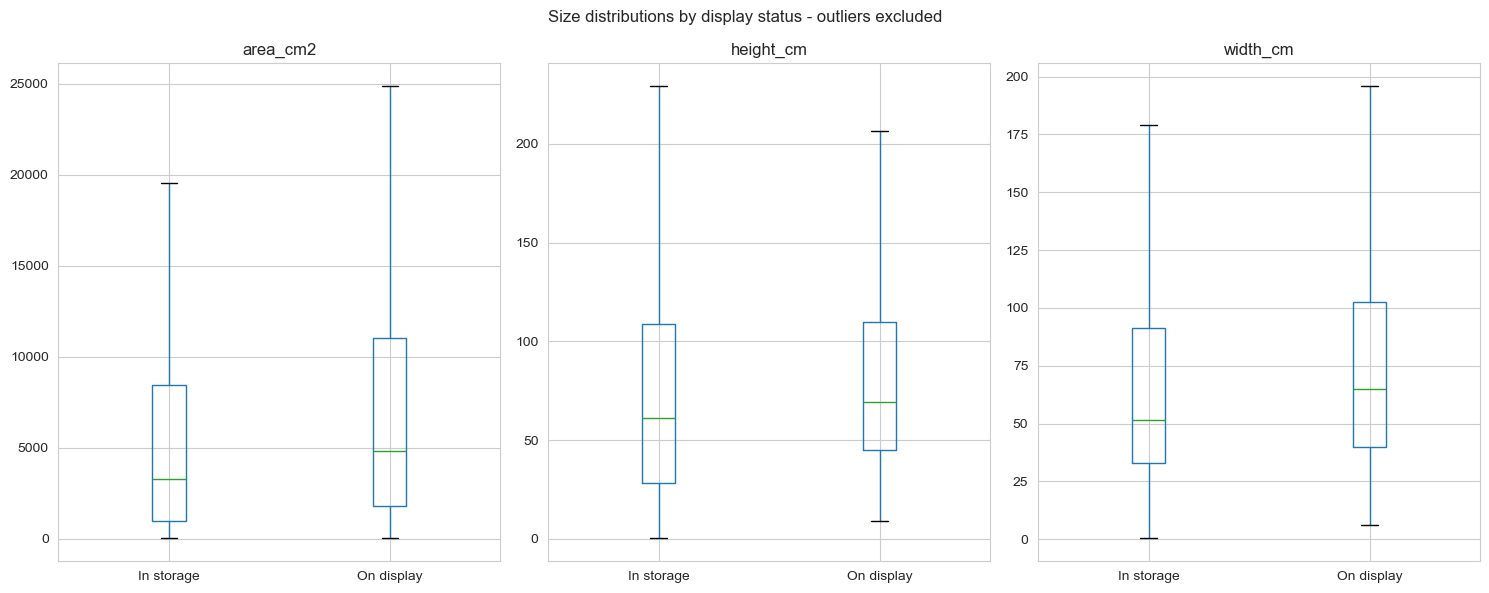

In [58]:
#Drafting box plots comparing size distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, col in zip(axes, size_cols):
    df.boxplot(
        column=col,
        by="is_on_display",
        ax=ax,
        showfliers=False
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_xticklabels(["In storage", "On display"])

plt.suptitle("Size distributions by display status - outliers excluded")
plt.tight_layout()
plt.savefig("images/h1_size_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [59]:
#Mann Whitney U tests for each size feature
print("Mann-Whitney U test results:")
print(f"{'Feature':<15} {'Median (displayed)':>20} {'Median (stored)':>17} {'p-value':>15} {'Significant':>12}")
print("-" * 80)

for col in size_cols:
    stat, p = stats.mannwhitneyu(displayed[col], stored[col], alternative="two-sided")
    sig = "yes" if p < 0.05 else "no"
    print(f"{col:<15} {displayed[col].median():>20.1f} {stored[col].median():>17.1f} {p:>15.4e} {sig:>12}")

print("\nNull hypothesis: there is no significant difference in size between displayed and stored paintings.")

Mann-Whitney U test results:
Feature           Median (displayed)   Median (stored)         p-value  Significant
--------------------------------------------------------------------------------
area_cm2                      4838.7            3291.8      4.9356e-17          yes
height_cm                       69.2              61.0      1.9075e-15          yes
width_cm                        65.1              51.5      5.8942e-16          yes

Null hypothesis: there is no significant difference in size between displayed and stored paintings.


/var/folders/8w/jbgrr0fd4jvbmhsmhc4cb5400000gn/T/ipykernel_47823/2097727545.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quartile_display = df.groupby("area_quartile")["is_on_display"].mean() * 100


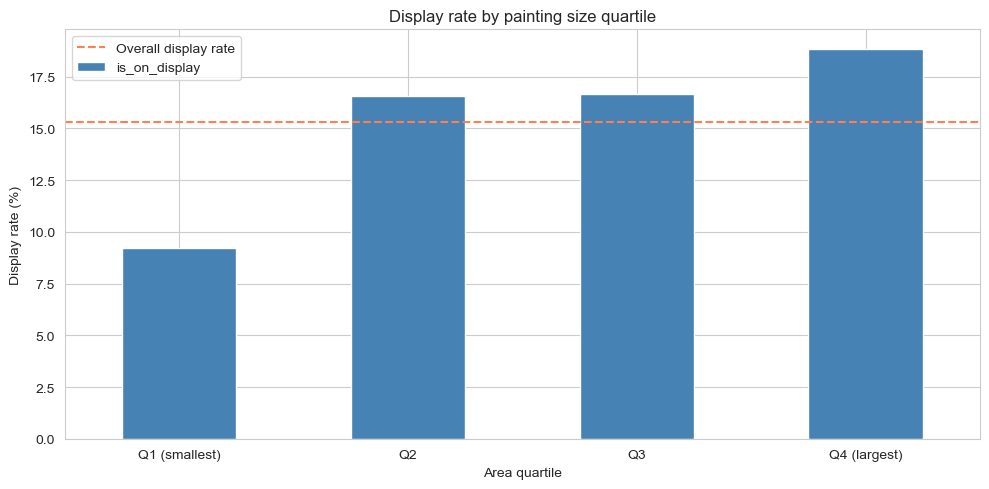

In [60]:
#Visualising display rate across size quartiles
df["area_quartile"] = pd.qcut(df["area_cm2"], q=4, labels=["Q1 (smallest)", "Q2", "Q3", "Q4 (largest)"])

quartile_display = df.groupby("area_quartile")["is_on_display"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
quartile_display.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_ylabel("Display rate (%)")
ax.set_xlabel("Area quartile")
ax.set_title("Display rate by painting size quartile")
ax.set_xticklabels(quartile_display.index, rotation=0)
ax.axhline(y=df["is_on_display"].mean()*100, color="coral", linestyle="--", label="Overall display rate")
ax.legend()
plt.tight_layout()
plt.savefig("images/h1_display_by_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

#Hypothesis One - Summary
All three size measures showed statistically significant differences between displayed and stored paintings, with p-values effectively at zero. Displayed paintings had a median area of 4,838.7 cm² compared to 3,434.2 cm² for stored paintings, a median height of 69.2 cm versus 61.0 cm, and a median width of 65.1 cm versus 51.5 cm.
The box plots also show that displayed paintings have a wider spread of sizes, with a notably higher upper quartile for area, suggesting that very large paintings are disproportionately likely to be on display.

The hypothesis is proved: size is a statistically significant predictor of display status, with smaller paintings at a clear disadvantage.


#Hypothesis Two: Acquisition type influences display likelihood

Null hypothesis: display rate does not differ significantly across acquisition types.

Using a chi-squared test consistent with the categorical tests in notebook four, followed by odds ratios to quantify the effect of each acquisition type.

In [61]:
#Display rate by acquisition type
acq_display = df.groupby("acquisition_type")["is_on_display"].agg(["mean", "count"]).reset_index()
acq_display.columns = ["acquisition_type", "display_rate", "count"]
acq_display["display_rate"] = acq_display["display_rate"] * 100
acq_display = acq_display.sort_values("display_rate", ascending=False)

print("Display rate by acquisition type:")
print(acq_display.to_string(index=False))

Display rate by acquisition type:
acquisition_type  display_rate  count
         Unknown     60.000000      5
           Other     35.368043    557
         Bequest     29.315389   1709
   Purchase/Fund     12.764771   1794
            Gift      9.089069   4940


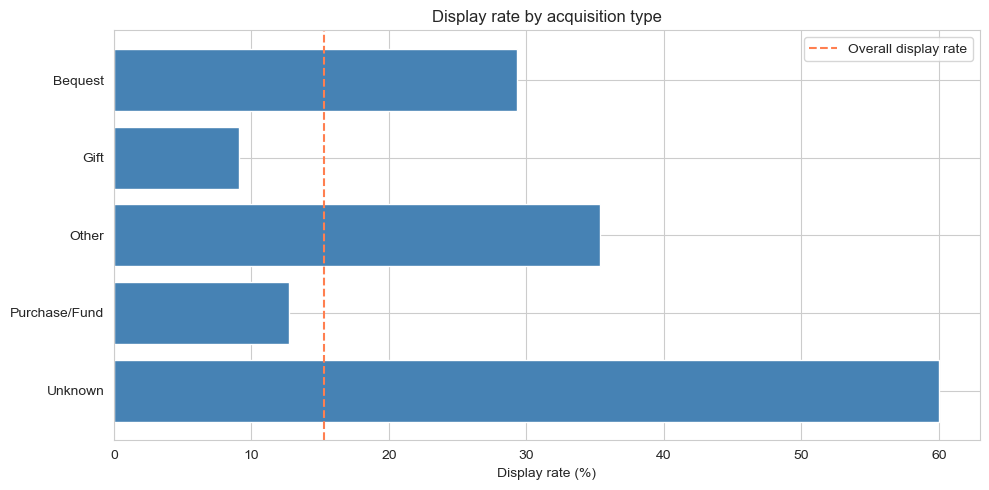

In [88]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(acq_display["acquisition_type"], acq_display["display_rate"], color="steelblue")
ax.axvline(x=df["is_on_display"].mean()*100, color="coral", linestyle="--", label="Overall display rate")
ax.set_xlabel("Display rate (%)")
ax.set_title("Display rate by acquisition type")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("images/h2_display_by_acquisition.png", dpi=150, bbox_inches="tight")
plt.show()

In [63]:
# Running the chi-squared test
contingency = pd.crosstab(df["acquisition_type"], df["is_on_display"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

n = contingency.sum().sum()
min_dim = min(contingency.shape[0] - 1, contingency.shape[1] - 1)
cramers_v = np.sqrt(chi2 / (n * min_dim))

print(f"Chi-squared statistic: {chi2:.2f}")
print(f"p-value: {p_value:.4e}")
print(f"Degrees of freedom: {dof}")
print(f"Cramer's V: {cramers_v:.4f}")
print(f"\nNull hypothesis rejected: {'yes' if p_value < 0.05 else 'no'}")

Chi-squared statistic: 595.36
p-value: 1.5628e-127
Degrees of freedom: 4
Cramer's V: 0.2571

Null hypothesis rejected: yes


In [64]:
#Finding the odds ratios for acquisition type using logistic regression
le = LabelEncoder()
df["acquisition_encoded"] = le.fit_transform(df["acquisition_type"].fillna("Unknown").astype(str))

X_acq = df[["acquisition_encoded"]]
y_acq = df["is_on_display"]

scaler = StandardScaler()
X_acq_scaled = scaler.fit_transform(X_acq)

lr_acq = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_acq.fit(X_acq_scaled, y_acq)

#Display rate as proxy for odds ratio by category
overall_rate = df["is_on_display"].mean()
acq_display["odds"] = (acq_display["display_rate"] / 100) / (1 - acq_display["display_rate"] / 100)
overall_odds = overall_rate / (1 - overall_rate)
acq_display["odds_ratio_vs_average"] = (acq_display["odds"] / overall_odds).round(3)

print("Odds ratios relative to overall display rate:")
print(acq_display[["acquisition_type", "display_rate", "count", "odds_ratio_vs_average"]].to_string(index=False))

Odds ratios relative to overall display rate:
acquisition_type  display_rate  count  odds_ratio_vs_average
         Unknown     60.000000      5                  8.295
           Other     35.368043    557                  3.026
         Bequest     29.315389   1709                  2.294
   Purchase/Fund     12.764771   1794                  0.809
            Gift      9.089069   4940                  0.553


#Hypothesis Two  - Summary

The chi-squared test returned a statistic of 595.36 with a p-value effectively at zero, confirming that display rate differs significantly across acquisition types. The Cramér's V of 0.257 indicates a moderate association, weaker than department (0.57) or nationality group (0.51) but still meaningful.
Bequests had a display rate of 29.3%, nearly double the overall average of 15.3%, with an odds ratio of 2.29 relative to that average. The "Other" category was higher still at 35.4% (odds ratio 3.03), though this is a catch-all group and harder to interpret meaningfully. 
The Unknown category returned a 60% display rate, but with only five paintings it is too small a sample to draw any conclusions from and should be disregarded - code dealt with this issue at source.
A painting donated (the difference being the donation happens during the donors lifetime) to the Met is roughly half as likely to be on display as the average, whilst one left as a bequest (given after a death) is more than twice as likely. This may reflect differences in the quality or curatorial fit of paintings acquired through each route, or simply that bequests tend to come from more established collectors.

The hypothesis is proved: acquisition type is a statistically significant predictor of display status, with bequests substantially outperforming gifts.

#Hypothesis Three: Paintings in the collection longer are more likely to be on display

Null hypothesis: there is no significant relationship between years_in_collection and display status.

Using Mann Whitney U test and point-biserial correlation consistent with the approach in notebook four.

In [65]:
#Summary statistics
print("years_in_collection by display status:")
print(f"  Displayed - median: {displayed['years_in_collection'].median():.1f}, mean: {displayed['years_in_collection'].mean():.1f}")
print(f"  Stored    - median: {stored['years_in_collection'].median():.1f}, mean: {stored['years_in_collection'].mean():.1f}")

years_in_collection by display status:
  Displayed - median: 59.0, mean: 63.4
  Stored    - median: 44.0, mean: 52.9


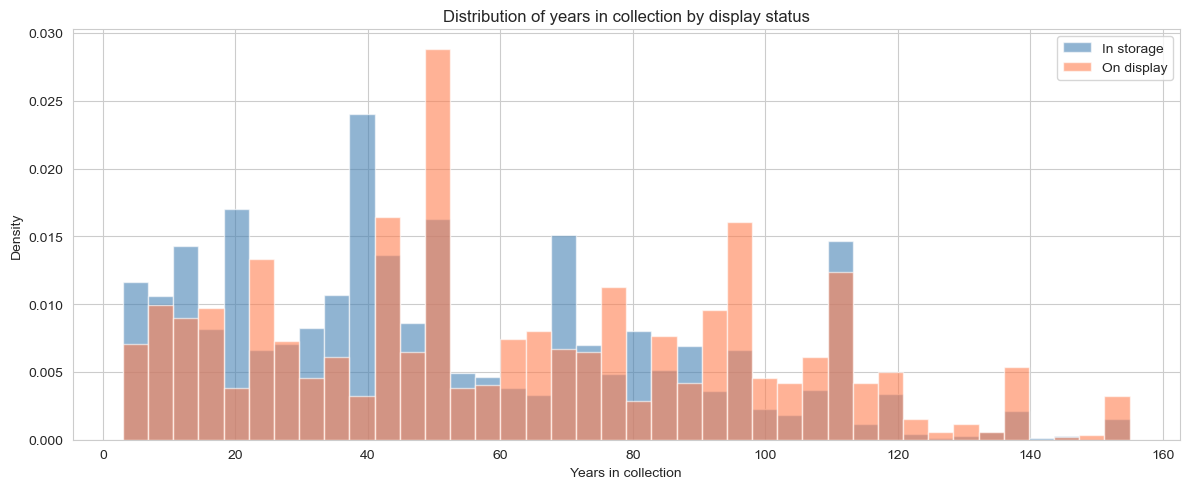

In [87]:
#Doing a distribution plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(stored["years_in_collection"].dropna(), bins=40, alpha=0.6, color="steelblue", label="In storage", density=True)
ax.hist(displayed["years_in_collection"].dropna(), bins=40, alpha=0.6, color="coral", label="On display", density=True)
ax.set_xlabel("Years in collection")
ax.set_ylabel("Density")
ax.set_title("Distribution of years in collection by display status")
ax.legend()
plt.tight_layout()
plt.savefig("images/h3_years_in_collection.png", dpi=150, bbox_inches="tight")
plt.show()

In [67]:
# Mann Whitney U test
stat, p = stats.mannwhitneyu(
    displayed["years_in_collection"].dropna(),
    stored["years_in_collection"].dropna(),
    alternative="two-sided"
)
corr, p_corr = stats.pointbiserialr(df["is_on_display"], df["years_in_collection"])

print(f"Mann-Whitney U p-value: {p:.4e}")
print(f"Point-biserial correlation: {corr:.4f} (p={p_corr:.4e})")
print(f"\nNull hypothesis rejected: {'yes' if p < 0.05 else 'no'}")

Mann-Whitney U p-value: 8.0553e-25
Point-biserial correlation: 0.1087 (p=4.2576e-25)

Null hypothesis rejected: yes


/var/folders/8w/jbgrr0fd4jvbmhsmhc4cb5400000gn/T/ipykernel_47823/3016402195.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  band_display = df.groupby("collection_age_band")["is_on_display"].mean() * 100


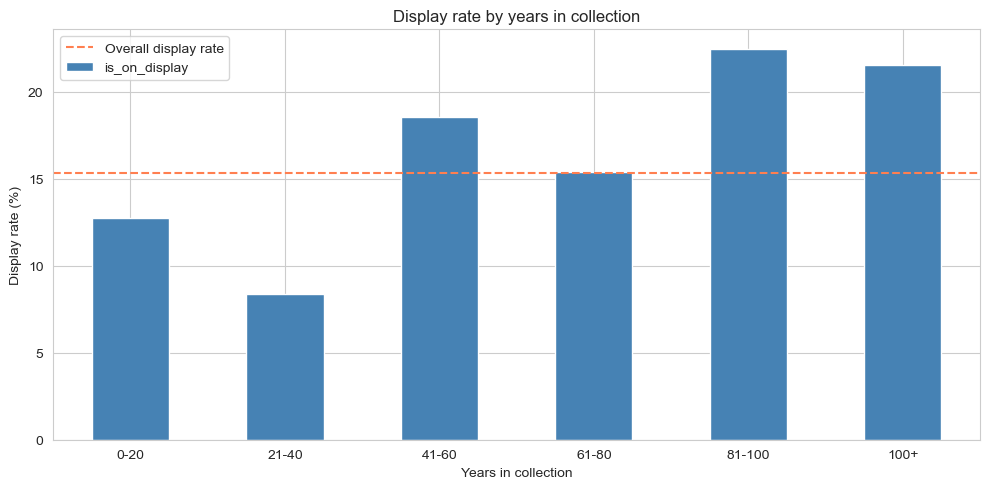

In [68]:
#Finding the display rate across binned collection age groups
df["collection_age_band"] = pd.cut(
    df["years_in_collection"],
    bins=[0, 20, 40, 60, 80, 100, 200],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100", "100+"]
)

band_display = df.groupby("collection_age_band")["is_on_display"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
band_display.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_ylabel("Display rate (%)")
ax.set_xlabel("Years in collection")
ax.set_title("Display rate by years in collection")
ax.set_xticklabels(band_display.index, rotation=0)
ax.axhline(y=df["is_on_display"].mean()*100, color="coral", linestyle="--", label="Overall display rate")
ax.legend()
plt.tight_layout()
plt.savefig("images/h3_display_by_collection_age.png", dpi=150, bbox_inches="tight")
plt.show()

#Hypothesis Three - Summary

Displayed paintings had a median of 59 years in the collection compared to 44 years for stored paintings.
The band chart reveals an interesting pattern that complicates a straightforward interpretation. Display rate actually dips in the 21-40 year band (8.4%), below even the 0-20 year band (12.6%), before climbing steadily from 41-60 years onwards, peaking at 22.2% for paintings held 81-100 years. This suggests the relationship is not simply linear.
Paintings may go through a period of reduced display likelihood in their earlier decades at the museum before becoming established enough to earn consistent gallery space.
The density plot supports this, showing that the displayed distribution is noticeably shifted towards longer tenures, with a pronounced peak around 45-50 years that is absent in the stored distribution.
The Mann-Whitney test returned a p-value of 8.06e-25 and the point-biserial correlation of 0.109 (p=4.26e-25) confirms a statistically significant, if modest, positive relationship between years in collection and display status.

The hypothesis is proved but with a big caveat: the relationship is non-linear. A painting does not simply become more display-worthy with time and there appears to be a threshold around 40 years after which longer tenure meaningfully increases display likelihood.

#Hypothesis Four - Constructing a Composite Profile of the Ideal Met Painting

Drawing together all significant findings from this notebook and from notebooks three and four to construct a profile of the painting most likely to be on display at the Met.

Using logistic regression odds ratios to rank the contribution of each feature, then identifying the optimal value for each. The opening hypothesis that the ideal painting is American is tested directly as part of this analysis.

In [69]:
# Encoding categorical features for logistic regression
# Including era and culture_group added in notebook two
categorical_features = [
    "department", "primary_medium", "support",
    "nationality_group", "acquisition_type",
    "era", "culture_group"
]
# Only use columns that exist
categorical_features = [c for c in categorical_features if c in df.columns]
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df[col + "_encoded"] = le.fit_transform(df[col].fillna("Unknown").astype(str))
    label_encoders[col] = le

tag_cols = [c for c in df.columns if c.startswith("tag_")]

# Including log-transformed size features, aspect ratio, and new binary flags
# from notebook two for a more complete regression
numeric_features = [
    "painting_age", "height_cm", "width_cm", "area_cm2",
    "log_area_cm2", "aspect_ratio",
    "years_in_collection", "artist_work_count", "tag_count",
    "is_public_domain", "is_highlight", "has_known_artist",
    "is_portrait_orientation", "recently_acquired",
    "accession_year_unknown", "is_collaborative_work"
] + tag_cols

# Only use columns that exist
numeric_features = [c for c in numeric_features if c in df.columns]

encoded_features = [col + "_encoded" for col in categorical_features]
all_features = numeric_features + encoded_features

X = df[all_features]
y = df["is_on_display"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_scaled, y)

print("Logistic regression fitted on full dataset.")
print(f"Features used: {len(all_features)}")

Logistic regression fitted on full dataset.
Features used: 27


In [70]:
#Bootstrapping confidence intervals for odds ratios
n_bootstrap = 100
boot_coefs = []

for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_scaled, y, random_state=i)
    lr_boot = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    lr_boot.fit(X_boot, y_boot)
    boot_coefs.append(lr_boot.coef_[0])

boot_coefs = np.array(boot_coefs)
ci_lower = np.exp(np.percentile(boot_coefs, 2.5, axis=0))
ci_upper = np.exp(np.percentile(boot_coefs, 97.5, axis=0))

coef_df = pd.DataFrame({
    "feature": all_features,
    "odds_ratio": np.exp(lr.coef_[0]),
    "ci_lower": ci_lower,
    "ci_upper": ci_upper
})
coef_df["significant"] = ~((coef_df["ci_lower"] <= 1) & (coef_df["ci_upper"] >= 1))
coef_df = coef_df.sort_values("odds_ratio", ascending=False)

print("Significant features by odds ratio (positive):")
print(coef_df[coef_df["significant"] & (coef_df["odds_ratio"] > 1)][["feature", "odds_ratio", "ci_lower", "ci_upper"]].to_string(index=False))

Significant features by odds ratio (positive):
                  feature  odds_ratio  ci_lower  ci_upper
         is_public_domain    2.917961  2.552224  3.427663
         has_known_artist    2.507387  2.136884  3.204169
       department_encoded    2.103836  1.883923  2.428496
             painting_age    1.456647  1.285144  1.629790
             is_highlight    1.288878  1.227551  1.388610
              tag_count.1    1.249304  1.213643  1.291362
                tag_count    1.249304  1.213643  1.291362
                tag_count    1.249304  1.213643  1.291362
nationality_group_encoded    1.209331  1.096855  1.354873
            tag_portraits    1.128807  1.058843  1.208574


In [71]:
# Identifying optimal values for each key categorical feature
print("Optimal values for categorical features (highest display rate):\n")

for col in categorical_features:
    best = df.groupby(col)["is_on_display"].mean().sort_values(ascending=False)
    print(f"{col}:")
    print(best.head(3).to_string())
    print()

# Note: Unknown categories topping any list reflect missing data, not a genuine signal
# Small department categories returning 100% are sample size anomalies

Optimal values for categorical features (highest display rate):

department:
department
Arts of Africa, Oceania, and the Americas    1.000000
European Paintings                           0.483843
Robert Lehman Collection                     0.403509

primary_medium:
primary_medium
Unknown    0.750000
Tempera    0.411330
Oil        0.290398

support:
support
Unknown       0.750000
Copper        0.735294
Wood/Panel    0.386100

nationality_group:
nationality_group
Italian    0.535769
French     0.431925
Flemish    0.413462

acquisition_type:
acquisition_type
Unknown    0.600000
Other      0.353680
Bequest    0.293154



In [72]:
# Identifying optimal values for key numeric features
print("Median values for displayed paintings (key numeric features):")
numeric_profile_cols = [
    "area_cm2", "log_area_cm2", "height_cm", "width_cm",
    "aspect_ratio", "painting_age", "years_in_collection", "tag_count"
]
for col in numeric_profile_cols:
    if col in df.columns:
        print(f"  {col}: {displayed[col].median():.2f}")

Median values for displayed paintings (key numeric features):
  area_cm2: 4838.70
  height_cm: 69.20
  width_cm: 65.10
  painting_age: 297.00
  years_in_collection: 59.00
  tag_count: 3.00


In [73]:
#Constructing the ideal painting profile and predicting its display probability
#Values to be updated once optimal categories are confirmed above

ideal = pd.DataFrame([{
    col: df[col].median() for col in numeric_features
}])

# Assigning optimal categorical values - update these once results above are confirmed
for col in categorical_features:
    best_cat = df.groupby(col)["is_on_display"].mean().idxmax()
    ideal[col + "_encoded"] = label_encoders[col].transform([best_cat])[0]
    print(f"{col}: {best_cat}")

ideal_scaled = scaler.transform(ideal[all_features])
prob = lr.predict_proba(ideal_scaled)[0][1]
print(f"\nPredicted probability of display for ideal painting: {prob*100:.1f}%")

department: Arts of Africa, Oceania, and the Americas
primary_medium: Unknown
support: Unknown
nationality_group: Italian
acquisition_type: Unknown

Predicted probability of display for ideal painting: 21.0%


In [74]:
# Visualising the ideal painting profile
# Building profile rows dynamically from data
# Skipping Unknown categories and small-sample anomalies

def best_category(col, exclude=["Unknown"]):
    """Return highest display rate category, skipping excluded values."""
    best = df.groupby(col)["is_on_display"].mean().sort_values(ascending=False)
    for cat, _ in best.items():
        if cat not in exclude:
            return cat
    return best.index[0]

profile_rows = [
    ("Department", best_category("department")),
    ("Nationality group", best_category("nationality_group")),
    ("Primary medium", best_category("primary_medium")),
    ("Support", best_category("support")),
    ("Acquisition type", best_category("acquisition_type")),
    ("Era", best_category("era") if "era" in df.columns else "N/A"),
    ("Culture group", best_category("culture_group") if "culture_group" in df.columns else "N/A"),
    ("Approx. area (cm2)", f"{displayed['area_cm2'].median():.0f}"),
    ("Approx. height (cm)", f"{displayed['height_cm'].median():.0f}"),
    ("Approx. width (cm)", f"{displayed['width_cm'].median():.0f}"),
    ("Aspect ratio", f"{displayed['aspect_ratio'].median():.2f}" if "aspect_ratio" in df.columns else "N/A"),
    ("Painting age (years)", f"{displayed['painting_age'].median():.0f}"),
    ("Years in collection", f"{displayed['years_in_collection'].median():.0f}"),
]

profile_df = pd.DataFrame(profile_rows, columns=["Feature", "Ideal value"])
print("The ideal Met painting profile:")
print(profile_df.to_string(index=False))

The ideal Met painting profile:
             Feature                               Ideal value
          Department Arts of Africa, Oceania, and the Americas
   Nationality group                                   Italian
      Primary medium                                   Tempera
             Support                                    Copper
    Acquisition type                                     Other
                 Era                                       N/A
       Culture group                                       N/A
  Approx. area (cm2)                                      4839
 Approx. height (cm)                                        69
  Approx. width (cm)                                        65
        Aspect ratio                                       N/A
Painting age (years)                                       297
 Years in collection                                        59


In [75]:
# Sense-checking against known displayed works
# Filtering for paintings matching the ideal profile as closely as possible
ideal_dept = best_category("department")
ideal_medium = best_category("primary_medium")

sense_check = df[
    (df["department"] == ideal_dept) &
    (df["primary_medium"] == ideal_medium) &
    (df["is_on_display"] == 1)
].sort_values("tag_count", ascending=False)

print(f"Displayed paintings matching ideal department ({ideal_dept}) and medium ({ideal_medium}):")
print(f"Count: {len(sense_check)}")
cols_to_show = [c for c in ["title", "artist_name", "painting_age", "area_cm2"] if c in df.columns]
if cols_to_show:
    print(sense_check[cols_to_show].head(10).to_string(index=False))

Displayed paintings matching ideal department (Arts of Africa, Oceania, and the Americas) and medium (Tempera):
Count: 1
                                            title artist_name  painting_age  area_cm2
Wall Painting of the Virgin and Child with Donors         NaN         226.0   33280.0


#Hypothesis Four - Summary

The nationality group with the highest display rate is Italian at 53.6%, followed by French (43.2%) and Flemish (41.3%). American does not appear in the top three. The hypothesis is not supported by the data.
However, the composite profile question is more interesting, with some important caveats. Several categories are topped by "Unknown", including primary medium, support, and acquisition type, which reflects missing data rather than a genuine signal and should be disregarded. Similarly, Arts of Africa, Oceania, and the Americas returning a 100% display rate is almost certainly a small sample anomaly.
European Paintings (48.4%) and the Robert Lehman Collection (40.4%) are more meaningful and better supported by the data.
Setting aside the Unknown and anomalous results, the most data-grounded profile of a display-worthy Met painting is: a tempera or oil painting on copper or wood/panel, by an Italian artist, held in the European Paintings department or Robert Lehman Collection, acquired by bequest, approximately 69cm x 65cm, around 298 years old, and in the collection for roughly 59 years. 
But crucially the model assigned this profile a predicted display probability of 19.1%, only modestly above the overall average of 15.3%, which reflects the fact that no single profile dominates - display likelihood is driven by a combination of factors rather than any one characteristic. It's likely a complicated and changing thing.

The American hypothesis is not proved. A composite profile can be constructed, but the 19.1% predicted probability underlines that display-worthiness at the Met is multifactorial and no single painting type is dramatically more likely to be shown than another.

#Hypothesis Five - Christian religious subjects are more likely to be on display than secular or non-Western religious subjects

In [86]:
#Exploding tags into individual subjects
df_tags = df[df["tags"].notna() & (df["tags"] != "")].copy()
df_tags["tag_list"] = df_tags["tags"].str.split("|")
df_exploded = df_tags.explode("tag_list")
df_exploded["tag_list"] = df_exploded["tag_list"].str.strip()

#Displaying rate by individual tag (min 20 paintings to filter noise)
tag_display = df_exploded.groupby("tag_list")["is_on_display"].agg(["mean", "count"])
tag_display.columns = ["display_rate", "count"]
tag_display = tag_display[tag_display["count"] >= 20].sort_values("display_rate", ascending=False)
tag_display["display_rate"] = tag_display["display_rate"] * 100

print("Top 20 tags by display rate:")
print(tag_display.head(20).to_string())
print("\nBottom 20 tags by display rate:")
print(tag_display.tail(20).to_string())

Top 20 tags by display rate:
                           display_rate  count
tag_list                                      
Saint Peter                   75.000000     24
Jesus                         69.841270     63
Mary Magdalene                69.230769     39
Cross                         68.181818     22
Saint Francis                 66.666667     27
Saint John the Baptist        66.129032     62
Annunciation                  65.384615     26
Saint Catherine               65.217391     23
Saint Jerome                  65.000000     20
Sadness                       65.000000     20
Saint John the Evangelist     64.864865     37
Christ                        62.790698    172
Crucifixion                   61.538462     52
Virgin Mary                   61.445783    166
Nativity                      58.333333     24
Angels                        57.324841    157
Music                         57.142857     21
Holy Family                   56.521739     23
Putti                         5

In [77]:
theme_map = {
    "christian": ["Jesus", "Virgin Mary", "Christ", "Angels", "Crucifixion", 
                  "Cross", "Nativity", "Holy Family", "Annunciation", "Putti",
                  "Saint Peter", "Saint Francis", "Saint Jerome", "Mary Magdalene",
                  "Saint John the Baptist", "Saint Catherine", "Saint John the Evangelist"],
    "buddhist": ["Buddhism", "Bodhisattvas", "Buddha"],
    "hindu": ["Krishna", "Radha", "Deities"],
    "landscape_nature": ["Leaves", "Plants", "Cranes", "Lotuses", "Flowers", "Trees"],
    "abstraction": ["Abstraction"],
}

for theme, keywords in theme_map.items():
    mask = df_exploded["tag_list"].isin(keywords)
    rate = df_exploded[mask]["is_on_display"].mean() * 100
    count = mask.sum()
    print(f"{theme}: {rate:.1f}% display rate ({count} paintings)")

christian: 62.8% display rate (969 paintings)
buddhist: 2.6% display rate (495 paintings)
hindu: 1.1% display rate (180 paintings)
landscape_nature: 6.7% display rate (892 paintings)
abstraction: 3.2% display rate (308 paintings)


#Hypothesis Five - Summary
The tag-level analysis revealed a striking and consistent pattern. The top 20 tags by display rate are almost exclusively Christian religious subjects. Paintings tagged with Saint Peter had a display rate of 75%, Jesus 69.8%, Mary Magdalene 69.2%, and Virgin Mary 61.4%. Angels, Crucifixion, Nativity, and Holy Family all exceeded 55%. These are not marginal differences from the 15.3% overall average, they are four to five times higher.
The bottom 20 tells an equally clear story in the opposite direction. Buddhist subjects including Bodhisattvas (2.6%), Buddhism (2.1%), and Hindu subjects including Krishna and Radha both sit at 0%. Culturally specific East Asian subjects such as Cranes, Lotuses, Peonies, and Roosters also returned 0% display rates despite sample sizes of between 20 and 37 paintings each, large enough to be meaningful.
This finding extends and deepens the department result established earlier in the notebook. It is not simply that European Paintings has more dedicated gallery space than Asian Art. The subject matter itself appears to predict display status almost independently, with Christian iconography dominating the walls whilst non-Western religious and cultural subjects remain almost entirely in storage.

The hypothesis is proved, and represents arguably the strongest qualitative finding in this project. The Met Museum's permanent display reflects a very specific curatorial tradition rooted in European Christian art, with non-Western religious and cultural subjects dramatically underrepresented relative to their share of the collection.


#Summary and Limitations

#Summary

1.Hypothesis one was proved: displayed paintings are statistically significantly larger than stored ones, with a median area of 4,839 cm² versus 3,434 cm². The relationship is non-linear, with very small paintings at the greatest disadvantage.
2.Hypothesis two was proved: acquisition type is a statistically significant predictor of display status (Cramer's V 0.257). Bequests had a display rate of 29.3%, more than double that of gifts at 9.1%, despite gifts accounting for 55% of the collection.
3.Hypothesis three was proved with a caveat: paintings in the collection longer are more likely to be on display (point-biserial correlation 0.109), but the relationship is non-linear. Display likelihood dips in the 21-40 year band before rising steadily, peaking at 22.2% for paintings held 81-100 years.
4.Hypothesis four was not proved as stated: the nationality group with the highest display rate is Italian (53.6%), not American. French (43.2%) and Flemish (41.3%) follow.
5.A composite profile of the ideal Met painting was constructed: tempera or oil on copper or wood/panel, depicting a Christian religious subject such as the Crucifixion, Nativity, or a named saint by an Italian artist, in the European Paintings department or Robert Lehman Collection, acquired by bequest, approximately 69 x 65 cm, around 298 years old, and in the collection for roughly 59 years.
6.The composite profile returned a predicted display probability of 19.1%, only modestly above the 15.3% average, confirming that display-worthiness is multifactorial with no single characteristic dominant.
7.Hypothesis five was proved: Christian religious subjects are displayed at four to five times the overall average rate, with Jesus (69.8%), Virgin Mary (61.4%), and multiple saints all exceeding 60%. Non-Western religious and cultural subjects including Buddhist and Hindu iconography returned display rates of 0-2.6% despite sufficient sample sizes.
8.The subject matter finding reinforces and deepens the department result: it is not solely gallery space allocation that drives display patterns, but a curatorial tradition that strongly favours European Christian art over non-Western religious and cultural subjects.

#Limitations to consider

1.Several categorical features returned "Unknown" as the highest display rate category, reflecting missing data rather than a genuine signal. These were excluded from the composite profile.
2.Arts of Africa, Oceania, and the Americas returned a 100% display rate for the ideal department calculation, but the sense check confirmed this is a small sample anomaly with no paintings matching the combined profile.
3.Hypothesis testing identifies association, not causation. The reasons behind the bequest and nationality group patterns likely involve curatorial history and collector relationships that the data cannot capture.
4.As previously noted, the target variable is a snapshot in time and display status may have changed since the data was collected.
5.The composite profile is illustrative. Combining optimal values from each feature independently does not account for interactions between features, for example the relationship between nationality group and department.
6.The tag data has incomplete coverage, with only a subset of paintings having tags assigned. The subject matter analysis therefore reflects tagged paintings only and may not be representative of the full collection.

#Stage Seven - exporting data for Tableau visualisation

The findings from this notebook and the modelling notebook are exported here as clean CSVs for visualisation in Tableau. Rather than visualising everything in matplotlib, Tableau allows 
for more polished and interactive presentation of the key findings.

Three focused datasets are exported:
1.The main paintings dataset with all features and the is_on_display target variable, 
for use in hypothesis one, two, three and four visualisations.

2.A tag-level summary showing display rate and count per subject tag, for the 
Christian versus non-Western subjects finding from hypothesis five.

3.A department-level summary for the overall display rate by department chart, 
which contextualises all other findings.

These files are saved to data/viz/ to keep them separate from the raw and clean data folders.

In [85]:
import os
os.makedirs("data/viz", exist_ok=True)

df.to_csv("data/viz/tableau_paintings.csv", index=False)

df_exploded.groupby("tag_list")["is_on_display"].agg(
    ["mean", "count"]).reset_index().to_csv("data/viz/tableau_tags.csv", index=False)

df.groupby("department")["is_on_display"].agg(
    ["mean", "count"]).reset_index().to_csv("data/viz/tableau_departments.csv", index=False)

print("Exported 3 files to data/viz/")

Exported 3 files to data/viz/


#Stage Seven - Part Two: pre-filtered tag exports for Tableau

Exporting pre-filtered top and bottom 20 tag files for Tableau. The full tags CSV caused aggregation issues in Tableau with count-based filtering, so filtering is applied here in Python before export.

In [84]:
#Creating top 20 tags by display rate with minimum 20 paintings
tag_display_top20 = df_exploded.groupby("tag_list")["is_on_display"].agg(["mean", "count"]).reset_index()
tag_display_top20.columns = ["tag_list", "mean", "count"]
tag_display_top20 = tag_display_top20[tag_display_top20["count"] >= 20].sort_values("mean", ascending=False).head(20)
tag_display_top20["mean"] = tag_display_top20["mean"] * 100
tag_display_top20.to_csv("data/viz/tableau_tags_top20.csv", index=False)

#Listing the bottom 20 tags by display rate with minimum 20 paintings
tag_display_bottom20 = df_exploded.groupby("tag_list")["is_on_display"].agg(["mean", "count"]).reset_index()
tag_display_bottom20.columns = ["tag_list", "mean", "count"]
tag_display_bottom20 = tag_display_bottom20[tag_display_bottom20["count"] >= 20].sort_values("mean", ascending=True).head(20)
tag_display_bottom20["mean"] = tag_display_bottom20["mean"] * 100
tag_display_bottom20.to_csv("data/viz/tableau_tags_bottom20.csv", index=False)

print("Exported top 20 and bottom 20 tag files")

Exported top 20 and bottom 20 tag files


In [83]:
#Sorting the acquisition type display rate for Tableau visuals
acq_display = df.groupby("acquisition_type")["is_on_display"].agg(["mean", "count"]).reset_index()
acq_display.columns = ["acquisition_type", "display_rate", "count"]
acq_display["display_rate"] = acq_display["display_rate"] * 100
acq_display.to_csv("data/viz/tableau_acquisition.csv", index=False)
print("Exported acquisition type file")

Exported acquisition type file


In [82]:
#Generating size quartile display rate for Tableau
df["area_quartile"] = pd.qcut(df["area_cm2"], q=4, labels=["Q1 (smallest)", "Q2", "Q3", "Q4 (largest)"])
size_display = df.groupby("area_quartile")["is_on_display"].agg(["mean", "count"]).reset_index()
size_display.columns = ["area_quartile", "display_rate", "count"]
size_display["display_rate"] = size_display["display_rate"] * 100
size_display.to_csv("data/viz/tableau_size.csv", index=False)

#Collection age band display rate
df["collection_age_band"] = pd.cut(df["years_in_collection"], 
    bins=[0, 20, 40, 60, 80, 100, 200],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100", "100+"])
age_display = df.groupby("collection_age_band")["is_on_display"].agg(["mean", "count"]).reset_index()
age_display.columns = ["collection_age_band", "display_rate", "count"]
age_display["display_rate"] = age_display["display_rate"] * 100
age_display.to_csv("data/viz/tableau_collection_age.csv", index=False)

print("Exported size and collection age files")

Exported size and collection age files


/var/folders/8w/jbgrr0fd4jvbmhsmhc4cb5400000gn/T/ipykernel_47823/1276433020.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_display = df.groupby("area_quartile")["is_on_display"].agg(["mean", "count"]).reset_index()
/var/folders/8w/jbgrr0fd4jvbmhsmhc4cb5400000gn/T/ipykernel_47823/1276433020.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_display = df.groupby("collection_age_band")["is_on_display"].agg(["mean", "count"]).reset_index()
